In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manideepreddy966/wearables-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wearables-dataset' dataset.
Path to dataset files: /kaggle/input/wearables-dataset


In [ ]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn xgboost neurokit2 tensorflow pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [3]:
print(path)

/kaggle/input/wearables-dataset


In [5]:
import pandas as pd


In [27]:
df1 = pd.read_csv(path + "/activity_environment_data.csv", sep=",", engine="python", on_bad_lines="skip")
df2 = pd.read_csv(path + "/digital_interaction_data.csv", sep=",", engine="python", on_bad_lines="skip")
df3 = pd.read_csv(path + "/personal_health_data.csv", sep=",", engine="python", on_bad_lines="skip")

df = df1.merge(df2, on=["User_ID", "Timestamp"], how="inner").merge(df3, on=["User_ID", "Timestamp"], how="inner")


In [29]:
df.columns

Index(['User_ID', 'Timestamp', 'Steps', 'Calories_Burned', 'Distance_Covered',
       'Exercise_Type', 'Exercise_Duration', 'Exercise_Intensity',
       'Ambient_Temperature', 'Battery_Level', 'Altitude', 'UV_Exposure',
       'Notifications_Received', 'Screen_Time', 'Age', 'Gender', 'Weight',
       'Height', 'Medical_Conditions', 'Medication', 'Smoker',
       'Alcohol_Consumption', 'Day_of_Week', 'Sleep_Duration',
       'Deep_Sleep_Duration', 'REM_Sleep_Duration', 'Wakeups', 'Snoring',
       'Heart_Rate', 'Blood_Oxygen_Level', 'ECG', 'Calories_Intake',
       'Water_Intake', 'Stress_Level', 'Mood', 'Skin_Temperature',
       'Body_Fat_Percentage', 'Muscle_Mass', 'Health_Score', 'Anomaly_Flag'],
      dtype='object')

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [38]:

# # ─────────────────────────────────────────────
# # 1. PREPROCESSING
# # ─────────────────────────────────────────────

# def preprocess(df):
#     df = df.copy()

#     # Drop non-feature columns
#     drop_cols = ["User_ID", "Timestamp", "Health_Score", "Anomaly_Flag"]
#     target = df["Health_Score"]
#     df = df.drop(columns=drop_cols)

#     # ── Categorical encoding decisions ──
#     # Binary / low-cardinality ordinal → Label Encode
#     binary_cols = ["Gender", "Smoker", "ECG"]
#     le = LabelEncoder()
#     for col in binary_cols:
#         if col in df.columns:
#             df[col] = df[col].astype(str)
#             df[col] = le.fit_transform(df[col])

#     # Nominal with few categories → One-Hot Encode
#     onehot_cols = ["Exercise_Type", "Exercise_Intensity", "Day_of_Week", "Mood"]
#     df = pd.get_dummies(df, columns=[c for c in onehot_cols if c in df.columns], drop_first=False)

#     # High-cardinality text fields → Frequency Encode (avoids OHE explosion)
#     freq_cols = ["Medical_Conditions", "Medication", "Alcohol_Consumption"]
#     for col in freq_cols:
#         if col in df.columns:
#             freq_map = df[col].astype(str).value_counts(normalize=True)
#             df[col] = df[col].astype(str).map(freq_map)

#     # ── Handle missing values ──
#     num_cols = df.select_dtypes(include=[np.number]).columns
#     df[num_cols] = df[num_cols].fillna(df[num_cols].median())

#     # ── Feature engineering ──
#     if "Weight" in df.columns and "Height" in df.columns:
#         df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

#     if "Deep_Sleep_Duration" in df.columns and "Sleep_Duration" in df.columns:
#         df["Deep_Sleep_Ratio"] = df["Deep_Sleep_Duration"] / (df["Sleep_Duration"] + 1e-5)

#     if "REM_Sleep_Duration" in df.columns and "Sleep_Duration" in df.columns:
#         df["REM_Sleep_Ratio"] = df["REM_Sleep_Duration"] / (df["Sleep_Duration"] + 1e-5)

#     if "Calories_Burned" in df.columns and "Calories_Intake" in df.columns:
#         df["Calorie_Balance"] = df["Calories_Intake"] - df["Calories_Burned"]

#     return df, target


# df_processed, target = preprocess(df)
# print(f"Features: {df_processed.shape[1]} | Samples: {df_processed.shape[0]}")



Features: 53 | Samples: 10000


In [41]:

# # ─────────────────────────────────────────────
# # 1. PREPROCESSING
# # ─────────────────────────────────────────────



def preprocess(df):
    df = df.copy()

    # Drop non-feature columns
    drop_cols = ["User_ID", "Timestamp", "Health_Score", "Anomaly_Flag"]
    target = df["Health_Score"] if "Health_Score" in df.columns else None
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # ── Categorical encoding decisions ──

    # Binary / low-cardinality ordinal → Label Encode
    binary_cols = ["Gender", "Smoker", "ECG"]
    le = LabelEncoder()
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])

    # Nominal with few categories → One-Hot Encode
    onehot_cols = ["Exercise_Type", "Exercise_Intensity", "Day_of_Week", "Mood"]
    df = pd.get_dummies(df, columns=[c for c in onehot_cols if c in df.columns], drop_first=False)

    # High-cardinality text fields → Frequency Encode
    freq_cols = ["Medical_Conditions", "Medication", "Alcohol_Consumption"]
    for col in freq_cols:
        if col in df.columns:
            freq_map = df[col].astype(str).value_counts(normalize=True)
            df[col] = df[col].astype(str).map(freq_map)

    # ── NEW: Catch-all for any remaining object columns ──
    # Try to coerce to numeric first (handles "1", "2.5", etc.)
    # If a column looks ordinal/categorical, label-encode it
    for col in df.select_dtypes(include=["object"]).columns:
        coerced = pd.to_numeric(df[col], errors="coerce")
        if coerced.notna().mean() > 0.8:
            # Mostly numeric strings — just cast
            df[col] = coerced
        else:
            # Treat as categorical → label encode
            print(f"  [auto label-encode] {col}: {df[col].unique()[:8]}")
            df[col] = le.fit_transform(df[col].astype(str))

    # ── Handle missing values ──
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # ── Feature engineering ──
    if "Weight" in df.columns and "Height" in df.columns:
        df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

    if "Deep_Sleep_Duration" in df.columns and "Sleep_Duration" in df.columns:
        df["Deep_Sleep_Ratio"] = df["Deep_Sleep_Duration"] / (df["Sleep_Duration"] + 1e-5)

    if "REM_Sleep_Duration" in df.columns and "Sleep_Duration" in df.columns:
        df["REM_Sleep_Ratio"] = df["REM_Sleep_Duration"] / (df["Sleep_Duration"] + 1e-5)

    if "Calories_Burned" in df.columns and "Calories_Intake" in df.columns:
        df["Calorie_Balance"] = df["Calories_Intake"] - df["Calories_Burned"]

    # ── Final safety cast: ensure all columns are numeric ──
    # This is the last line of defence before XGBoost sees the data
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.fillna(df.median())

    # Sanity check
    remaining_obj = df.select_dtypes(include=["object"]).columns.tolist()
    if remaining_obj:
        raise ValueError(f"Still have object columns after preprocessing: {remaining_obj}")

    return df, target


df_processed, target = preprocess(df)
print(f"Features: {df_processed.shape[1]} | Samples: {df_processed.shape[0]}")


  [auto label-encode] Snoring: ['Yes' 'No']
  [auto label-encode] Stress_Level: ['Moderate' 'High' 'Low']
Features: 53 | Samples: 10000


In [42]:

# ─────────────────────────────────────────────
# 2. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    df_processed, target, test_size=0.2, random_state=42
)



In [43]:

# ─────────────────────────────────────────────
# 3. MODEL — XGBoost with tuned hyperparameters
# ─────────────────────────────────────────────

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,       # L1 regularisation
    reg_lambda=1.0,      # L2 regularisation
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="rmse",
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [44]:

# ─────────────────────────────────────────────
# 4. EVALUATION
# ─────────────────────────────────────────────

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

# Cross-validated RMSE (more reliable than single split)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = np.sqrt(-cross_val_score(
    xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    df_processed, target, scoring="neg_mean_squared_error", cv=cv
))

print(f"\n── Evaluation ──────────────────────")
print(f"Test RMSE       : {rmse:.4f}")
print(f"Test MAE        : {mae:.4f}")
print(f"CV RMSE (5-fold): {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")




── Evaluation ──────────────────────
Test RMSE       : 0.9413
Test MAE        : 0.7455
CV RMSE (5-fold): 0.9608 ± 0.0085


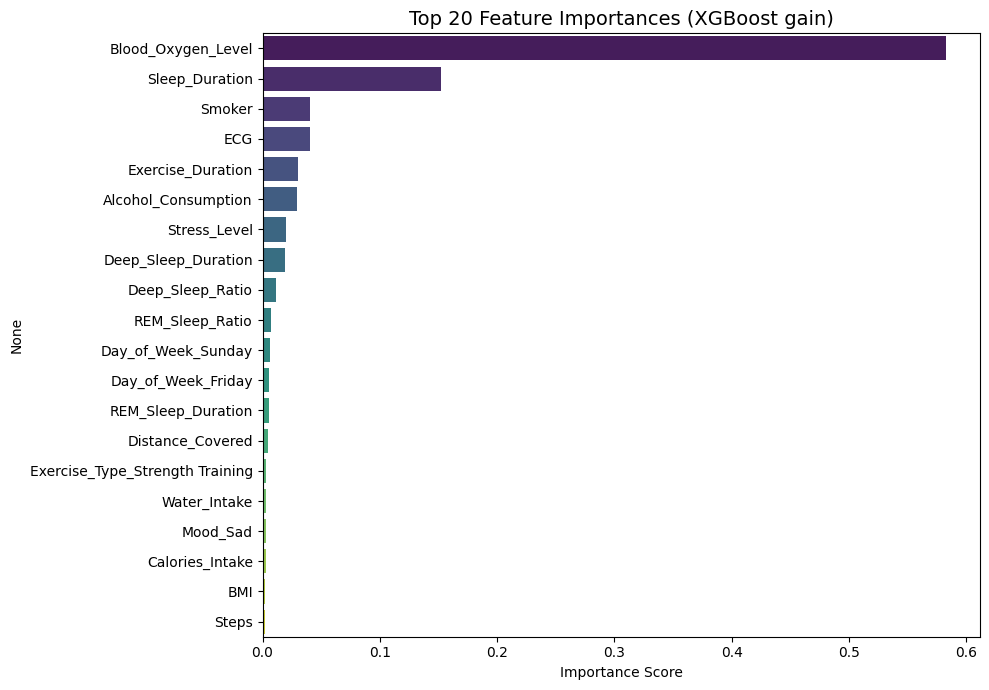


Top 10 features:
 Blood_Oxygen_Level     0.582443
Sleep_Duration         0.152510
Smoker                 0.040880
ECG                    0.040075
Exercise_Duration      0.030549
Alcohol_Consumption    0.029789
Stress_Level           0.020221
Deep_Sleep_Duration    0.019316
Deep_Sleep_Ratio       0.011782
REM_Sleep_Ratio        0.007213
dtype: float32


In [45]:

# ─────────────────────────────────────────────
# 5. FEATURE IMPORTANCE
# ─────────────────────────────────────────────

importances = pd.Series(model.feature_importances_, index=df_processed.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 20 Feature Importances (XGBoost gain)", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("\nTop 10 features:\n", top_features.head(10))



In [46]:

# ─────────────────────────────────────────────
# 6. PREDICTION FUNCTION (ready for LLM layer)
# ─────────────────────────────────────────────

FEATURE_COLS = df_processed.columns.tolist()  # save for inference

def predict_health_score(user_row_raw: pd.DataFrame):
    """
    Takes a raw single-user DataFrame row (same schema as df),
    preprocesses it, and returns:
      - predicted health score
      - dict of top contributing features (for LLM context)
    """
    user_processed, _ = preprocess(
        pd.concat([user_row_raw, df.head(1)])  # concat to stabilise encoding
    )
    user_processed = user_processed.iloc[[0]].reindex(columns=FEATURE_COLS, fill_value=0)

    score = model.predict(user_processed)[0]

    # SHAP-style approximation using feature importances × feature values
    contrib = pd.Series(
        model.feature_importances_ * np.abs(user_processed.values[0]),
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    return {
        "predicted_health_score": round(float(score), 2),
        "top_contributing_features": contrib.head(10).to_dict(),
    }


# ── Quick test ──
sample_user = df.sample(1, random_state=7).drop(columns=["Health_Score", "Anomaly_Flag"])
result = predict_health_score(sample_user)
print("\n── Sample Prediction ───────────────")
print(f"Predicted Health Score : {result['predicted_health_score']}")
print("Top Contributing Features:")
for feat, val in result["top_contributing_features"].items():
    print(f"  {feat:<35} {val:.4f}")

  [auto label-encode] Snoring: ['No' 'Yes']
  [auto label-encode] Stress_Level: ['High' 'Moderate']

── Sample Prediction ───────────────
Predicted Health Score : 47.56
Top Contributing Features:
  Blood_Oxygen_Level                  56.8626
  Steps                               19.1022
  Calories_Intake                     5.8182
  Altitude                            3.3664
  Calorie_Balance                     0.8679
  Sleep_Duration                      0.6500
  Calories_Burned                     0.4762
  Heart_Rate                          0.2605
  Height                              0.2265
  Muscle_Mass                         0.1456


In [47]:
print(df["Health_Score"].describe())

count    10000.000000
mean        49.692650
std         17.816732
min          0.000000
25%         36.324657
50%         49.577094
75%         62.954154
max        100.000000
Name: Health_Score, dtype: float64


In [50]:
import joblib

model_artifacts = {
    "model": model,
    "feature_cols": FEATURE_COLS,
}

joblib.dump(model_artifacts, "health_score_model.joblib")
print("Model saved to health_score_model.joblib")

# Load
artifacts = joblib.load("health_score_model.joblib")

Model saved to health_score_model.joblib
